# Proyecto LOST — Learning-based Orientation and Steering for Traversal

**Ambiente:** Gymnasium `MountainCarContinuous-v0` · **Técnicas:** Q-Learning tabular y Dyna-Q

El rover debe aprender, únicamente a partir de la recompensa, que juntar impulso
oscilando es mejor que quedarse quieto. Esta notebook cubre las cuatro tareas de
la letra:

1. **Discretización** de los espacios continuos de observaciones y acciones, con un estudio de distintas resoluciones.
2. **Q-Learning** como técnica de aprendizaje.
3. **Exploración de hiperparámetros**, justificando la forma de evaluar y la elección final.
4. **Componente de investigación:** Dyna-Q (Sutton & Barto, *Reinforcement Learning: An Introduction*, 2.ª ed., §8.1–8.2), con análisis y experimentación similares a Q-Learning.

Los entrenamientos pesados viven en `experiments.py` (suites: `discretization`,
`discretization_a4`, `hyperparams`, `hyperparams_a4`, `dynaq`, `final`); esta
notebook reproduce una corrida corta de demostración y luego carga y analiza los
resultados completos (`results/*.csv`, `models/*.pkl`).

In [1]:
import csv
import numpy as np
import gymnasium as gym
from IPython.display import Image, display

from discretization import Discretizer
from q_learning_agent import QLearningAgent
from dyna_q_agent import DynaQAgent

def show_csv(path, cols=None, sort_by=None, limit=None):
    with open(path) as f:
        rows = list(csv.DictReader(f))
    if sort_by:
        rows.sort(key=lambda r: -float(r[sort_by]))
    if limit:
        rows = rows[:limit]
    cols = cols or list(rows[0].keys())
    widths = [max(len(c), *(len(r[c]) for r in rows)) for c in cols]
    print("  ".join(c.ljust(w) for c, w in zip(cols, widths)))
    for r in rows:
        print("  ".join(r[c].ljust(w) for c, w in zip(cols, widths)))

env = gym.make("MountainCarContinuous-v0")
print("espacio de observaciones:", env.observation_space)
print("espacio de acciones:     ", env.action_space)

espacio de observaciones: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
espacio de acciones:      Box(-1.0, 1.0, (1,), float32)


## El ambiente

- **Observación** (continua): posición $x \in [-1.2, 0.6]$ y velocidad $v \in [-0.07, 0.07]$.
- **Acción** (continua): un acelerador $a \in [-1, 1]$ (negativo = empujar a la izquierda, positivo = a la derecha).
- **Recompensa:** $-0.1\,a^2$ en cada paso, más $+100$ al alcanzar la bandera en $x \ge 0.45$.
- Los episodios se truncan a los 999 pasos.

Dos propiedades condicionan todo lo que sigue:

- El motor es demasiado débil para subir directo, así que la única solución es **oscilar** y acumular impulso.
- La recompensa es **dispersa y engañosa**: hasta que el +100 se descubre (y se propaga), el comportamiento que maximiza el retorno es no hacer nada ($a=0$ cuesta 0). "Quedarse quieto" es un óptimo local fuerte, y veremos a Q-Learning puro caer en él.

## Tarea 1 — Discretización

Q-Learning tabular necesita conjuntos finitos de estados y acciones, así que
ambos espacios se mapean a **grillas uniformes** (`discretization.py`):

- La grilla de estados coloca `position_bins` × `velocity_bins` bordes con `np.digitize`; una observación continua se convierte en un par de enteros `(x_bin, vel_bin)`.
- El conjunto de acciones son `num_actions` valores de acelerador equiespaciados en $[-1, 1]$.

La tabla Q tiene forma `(position_bins+1, velocity_bins+1, num_actions)`. El compromiso de resolución:

- **Demasiado gruesa** → aliasing: estados físicamente distintos (p. ej. moviéndose rápido vs. lento hacia la izquierda) comparten una celda y un valor, y la política no puede distinguir situaciones que requieren acciones distintas.
- **Demasiado fina** → la tabla explota y cada celda se visita rara vez, por lo que los valores tardan mucho más en volverse precisos (aprendizaje más lento con el mismo número de episodios) y no hay generalización alguna entre celdas vecinas.
- **Cantidad de acciones:** con una cantidad **par** no existe la acción de acelerador 0: el agente siempre paga costo y siempre aplica fuerza. Con una cantidad **impar**, el 0 existe — barato, pero también la puerta al óptimo local del "quieto". Más acciones = control más fino pero tabla más grande y más carga de exploración.

In [2]:
disc = Discretizer(position_bins=20, velocity_bins=20, num_actions=5)
print(disc.describe())
print("forma de la tabla Q:", disc.q_table_shape)
obs = np.array([-0.4, 0.02])
print("observación", obs, "-> estado", disc.state(obs))
print("índice de acción 3 -> acción del ambiente", disc.action(3))

20x20 state grid (441 states), 5 actions
forma de la tabla Q: (21, 21, 5)
observación [-0.4   0.02] -> estado (9, 13)
índice de acción 3 -> acción del ambiente [0.5]


## Tarea 2 — Q-Learning

`q_learning_agent.py` implementa Q-Learning de un paso (control TD off-policy):

$$Q(S,A) \leftarrow Q(S,A) + \alpha\,\big[R + \gamma \max_a Q(S',a) - Q(S,A)\big]$$

con política de comportamiento **ε-greedy**. Épsilon parte de 1.0 (la meta solo
puede descubrirse por azar, así que el inicio debe ser casi totalmente
aleatorio) y decae multiplicativamente por episodio hasta un piso
`epsilon_min`. En la terminación verdadera (meta alcanzada) se elimina el
término de *bootstrap* — el valor de un estado terminal es 0 por definición —;
en el truncamiento a 999 pasos se mantiene, porque el límite de tiempo es un
artefacto y no un estado terminal real.

Abajo, una corrida corta a propósito para que la interacción con el simulador
se vea de punta a punta (los experimentos reales son de 3 000–10 000 episodios):

In [3]:
demo = QLearningAgent(Discretizer(20, 20, 5), seed=0)
env = gym.make("MountainCarContinuous-v0")
history = demo.train_agent(env, episodes=300, log_every=100)
print(f"300 episodios entrenados en {history['train_seconds']:.1f}s; "
      f"la meta se alcanzó en {sum(history['success'])} de ellos")

episode 100/300 avg_reward=-45.4 success_rate=0.02 epsilon=0.905


episode 200/300 avg_reward=-42.9 success_rate=0.00 epsilon=0.819


episode 300/300 avg_reward=-37.9 success_rate=0.01 epsilon=0.741
300 episodios entrenados en 7.2s; la meta se alcanzó en 3 de ellos


## Metodología de evaluación

El retorno de entrenamiento es ruidoso y está contaminado por ε, así que toda
configuración se puntúa igual al terminar: **100 episodios con la política
greedy** (sin exploración) sobre un **conjunto fijo y sembrado de estados
iniciales**, idéntico entre corridas. Reportamos retorno medio, desvío estándar
y **tasa de éxito** (fracción de episodios que llegan a la bandera). Cada
configuración se entrena con **2 semillas** para separar el efecto de un
parámetro de la suerte de la corrida. Como un episodio exitoso vale ≈ +90 (100
menos combustible) y uno fallido ≈ 0, el retorno medio y la tasa de éxito
cuentan una historia consistente.

### Resultados de discretización (`experiments.py discretization` y `discretization_a4`)

Hiperparámetros fijos (α=0.1, γ=0.99, ε: 1.0 → 0.05 con decaimiento 0.999,
3 000 episodios); primero la grilla de estados, luego la cantidad de acciones.

In [4]:
print("--- grillas de estados y cantidades de acciones, hiperparámetros base (5 acciones salvo indicación) ---")
show_csv("results/discretization_summary.csv",
         cols=["run_id", "eval_mean_reward", "eval_std_reward", "eval_success_rate",
               "train_success_rate_last500", "train_seconds"])
print()
print("--- grillas de estados sobre el conjunto de 4 acciones (ver análisis abajo) ---")
show_csv("results/discretization_a4_summary.csv",
         cols=["run_id", "eval_mean_reward", "eval_std_reward", "eval_success_rate",
               "eval_mean_steps", "train_seconds"])

--- grillas de estados y cantidades de acciones, hiperparámetros base (5 acciones salvo indicación) ---
run_id                  eval_mean_reward   eval_std_reward     eval_success_rate  train_success_rate_last500  train_seconds     
disc_grid10x10_a5_s0    0.0                0.0                 0.0                0.0                         51.090136496000014
disc_grid10x10_a5_s1    0.0                0.0                 0.0                0.0                         51.380723171      
disc_grid20x20_a5_s0    0.0                0.0                 0.0                0.0                         51.89838185999997 
disc_grid20x20_a5_s1    0.0                0.0                 0.0                0.0                         53.557593682000004
disc_grid50x50_a5_s0    0.0                0.0                 0.0                0.0                         54.12830411499999 
disc_grid50x50_a5_s1    0.0                0.0                 0.0                0.0                         56.644753780

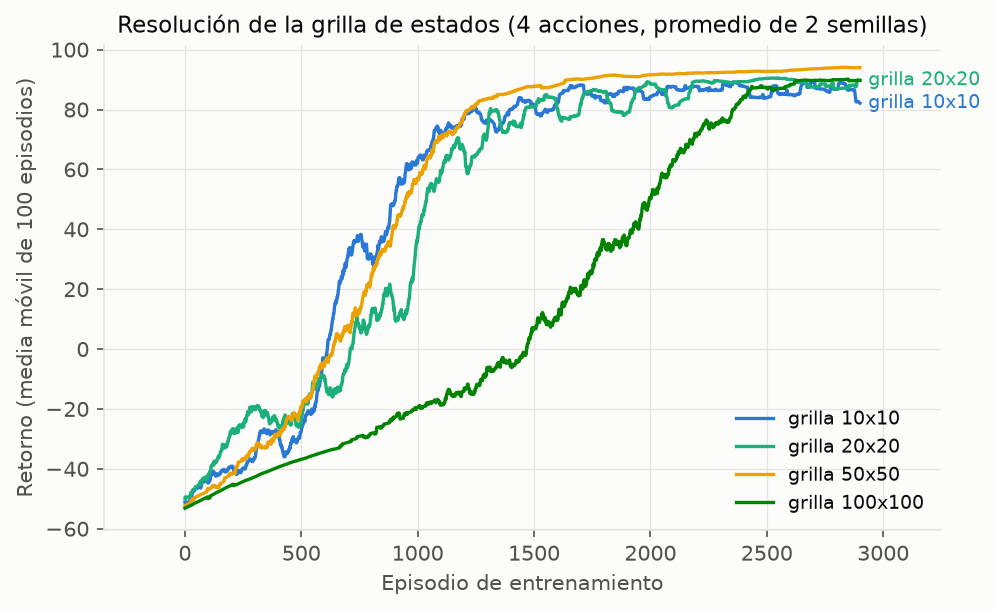

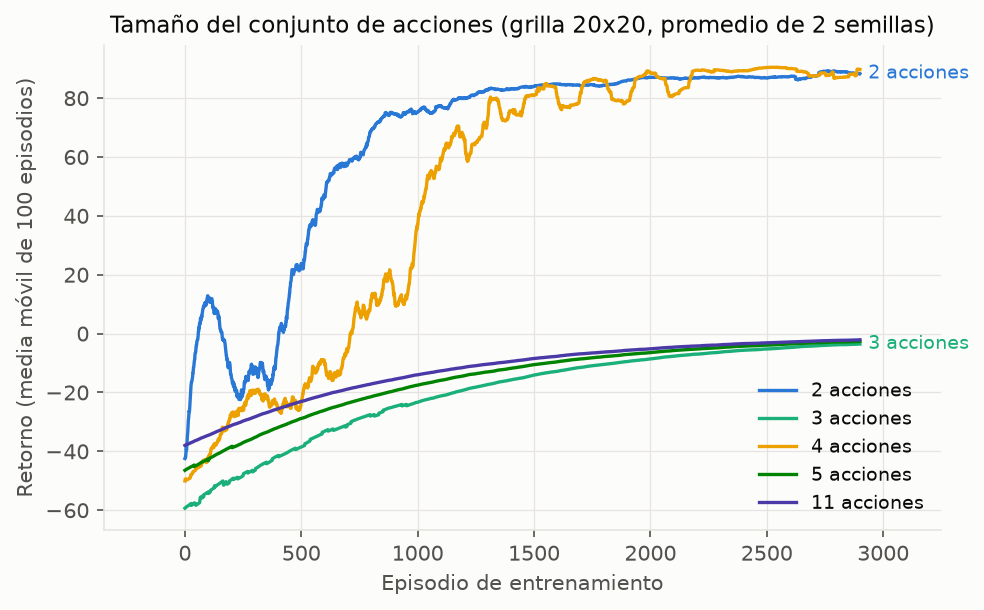

In [5]:
display(Image("results/es/fig1_discretization_grids.png"))
display(Image("results/es/fig2_discretization_actions.png"))

### Análisis — el conjunto de acciones decide todo

El primer barrido (grillas de estados con **5 acciones**) produjo una pared de
ceros: toda resolución, toda semilla, retorno de evaluación 0.0 y 0% de éxito.
La política aprendida es *"no hacer nada"*. Es la trampa de la recompensa
engañosa descrita arriba: la acción de acelerador 0 no cuesta nada, la
exploración aleatoria llega a la bandera solo en ~2% de los episodios, y el
backup de un paso arrastra el +100 hacia atrás una celda por éxito — demasiado
lento para 3 000 episodios. Cuando el aprendizaje colapsa así, la resolución de
la grilla es irrelevante.

El **barrido por cantidad de acciones** expone la variable real. Las cantidades
son impares (3, 5, 11 — el conjunto contiene el acelerador 0) o pares (2, 4 —
no lo contiene):

- **Impares: retorno 0.0, 0% de éxito**, en toda corrida y semilla.
- **Pares: resuelto.** 2 acciones ≈ 88 de retorno / 100% de éxito; 4 acciones ≈ 85–92 / 98–100%.

Quitar la acción "quieto" elimina el óptimo local *estructuralmente*: toda
política debe moverse, así que el auto no puede converger a quedarse parado, y
el movimiento constante funciona además como exploración. Esta única decisión
de discretización logra lo que ningún hiperparámetro de abajo consigue de forma
confiable. 4 acciones superan levemente a 2 porque los aceleradores ±1/3
permiten gastar menos combustible cuando alcanza con un empujón suave.

Con un conjunto de acciones resoluble (4), el **barrido de grillas** se vuelve
informativo y muestra el compromiso clásico de resolución:

- **10×10** — aliasing fuerte: 6–43 de retorno, 49–77% de éxito. Las celdas mezclan estados que necesitan acciones opuestas.
- **20×20** — la mejor: 85–92 de retorno, 98–100% de éxito, y las soluciones más rápidas (~160–180 pasos).
- **50×50 / 100×100** — igual resuelven (78–92) pero con trayectorias visiblemente más lentas y toscas (hasta ~550 pasos en 100×100): con 40 veces más celdas, cada celda recibe 40 veces menos datos en los mismos 3 000 episodios.

**Discretización elegida: grilla de estados 20×20 × 4 acciones** (441 estados —
suficientemente chica para visitarse a fondo, suficientemente fina para separar
los estados de impulso que importan).

## Tarea 3 — Exploración de hiperparámetros (`experiments.py hyperparams` y `hyperparams_a4`)

Estrategia: una grilla completa sobre 5 parámetros es inabordable, así que
barremos **un parámetro por vez alrededor de una configuración base** (búsqueda
por coordenadas) — α ∈ {0.05, 0.1*, 0.2, 0.5}, γ ∈ {0.9, 0.99*, 0.999, 1.0},
decaimiento de ε ∈ {0.997, 0.999*, 0.9995}, piso de ε ∈ {0.0, 0.05*, 0.2}
(* = valor base), 2 semillas cada uno, puntuado con el protocolo de evaluación
de arriba.

--- barridos sobre la discretización de 5 acciones ---
run_id                     eval_mean_reward   eval_success_rate  train_success_rate_last500
hp_base_s0                 0.0                0.0                0.0                       
hp_base_s1                 0.0                0.0                0.0                       
hp_alpha0.05_s0            0.0                0.0                0.0                       
hp_alpha0.05_s1            0.0                0.0                0.0                       
hp_alpha0.2_s0             0.0                0.0                0.0                       
hp_alpha0.2_s1             0.0                0.0                0.0                       
hp_alpha0.5_s0             83.51375000000003  0.99               1.0                       
hp_alpha0.5_s1             0.0                0.0                0.0                       
hp_gamma0.9_s0             0.0                0.0                0.0                       
hp_gamma0.9_s1           

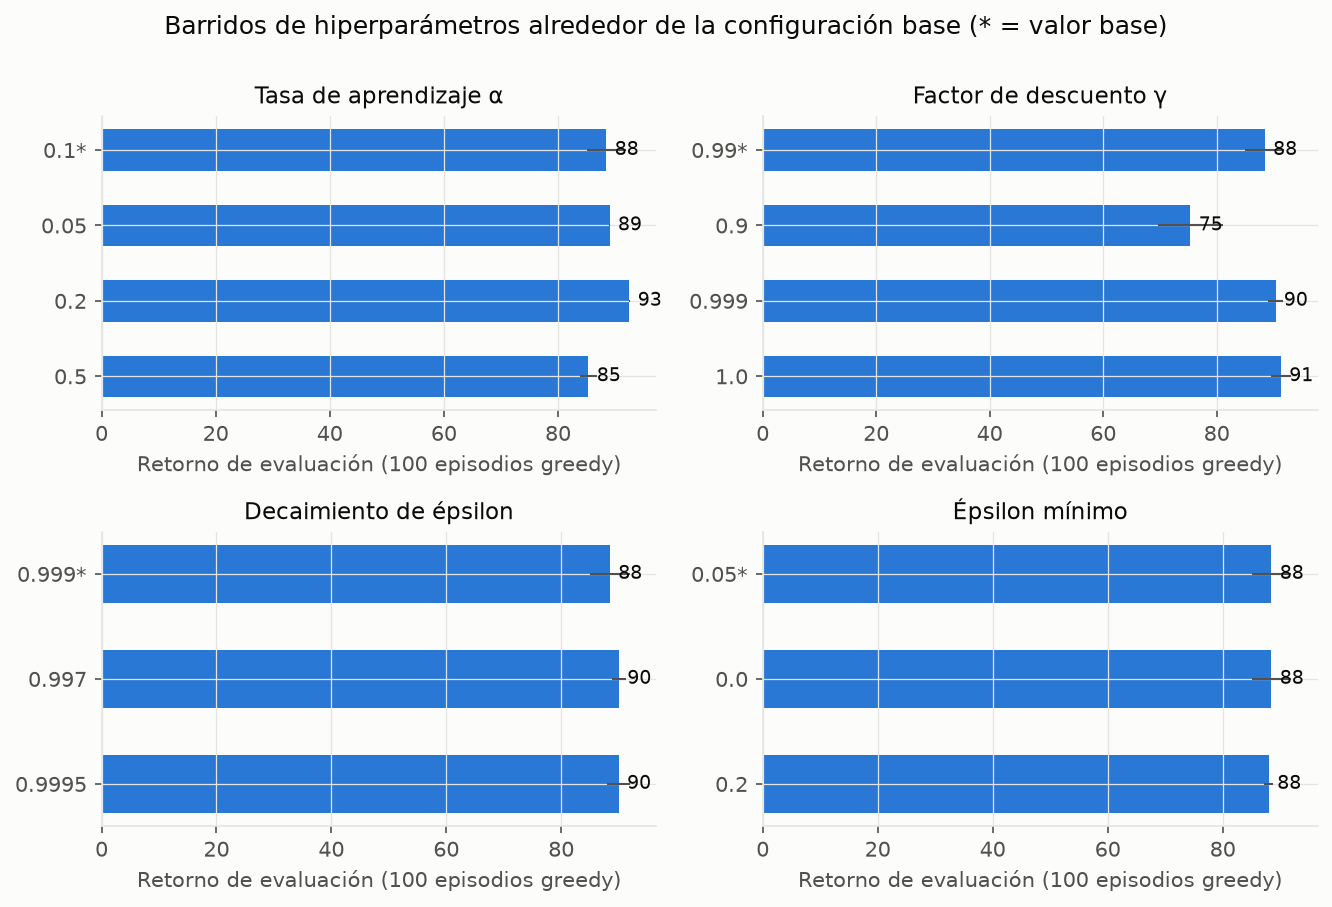

In [6]:
print("--- barridos sobre la discretización de 5 acciones ---")
show_csv("results/hyperparams_summary.csv",
         cols=["run_id", "eval_mean_reward", "eval_success_rate",
               "train_success_rate_last500"])
print()
print("--- barridos sobre la discretización elegida de 4 acciones ---")
show_csv("results/hyperparams_a4_summary.csv",
         cols=["run_id", "eval_mean_reward", "eval_success_rate",
               "train_success_rate_last500"])
display(Image("results/es/fig3_hyperparams.png"))

### Análisis

**Sobre la discretización de 5 acciones** (primera tabla) el barrido es casi
uniformemente cero: ninguna tasa de aprendizaje, descuento ni esquema de
épsilon rescata la trampa del "quieto" en 3 000 episodios. La única excepción
es instructiva: α = 0.5 escapó en una semilla (83.5) y falló en la otra (0.0).
Una tasa de aprendizaje grande deja que un único éxito afortunado mueva los
valores Q lo suficiente para redirigir la política greedy, pero es una moneda
al aire, no un método. (Una prueba aparte confirmó que α = 0.5 con piso de ε
0.2 y 8 000 episodios escapa de forma confiable — ver los modelos finales.)

**Sobre la discretización elegida de 4 acciones** (segunda tabla y figura) las
diferencias se vuelven medibles y consistentes entre semillas:

- **α (tasa de aprendizaje):** 0.2 es la mejor (92.5 de media; 92.6/92.4 por semilla). 0.05–0.1 quedan apenas atrás (88.5–89.0) y 0.5 empieza a doler (85.3) — actualizaciones tan grandes que los valores no terminan de asentarse.
- **γ (descuento):** el único parámetro con un modo de falla claro. γ = 0.9 cae a 75.4: el +100 está a ~150 pasos al principio, y $0.9^{150} \approx 10^{-7}$ lo vuelve casi invisible desde los estados iniciales. γ ∈ {0.99, 0.999, 1.0} son equivalentes acá (88.5–91.3); mantenemos el convencional 0.99.
- **Esquema de ε (decaimiento, piso):** apenas importa en esta discretización (88.0–90.1 en todo el rango) porque el movimiento forzado ya explora; el esquema solo regula qué tan rápido sube la curva de retorno.

**Elección final: α = 0.2, γ = 0.99, ε: 1.0 → 0.05 con decaimiento 0.999**,
sobre la discretización 20×20 × 4 acciones.

## Tarea 4 — Componente de investigación: Dyna-Q (Sutton & Barto §8.1–8.2)

Las secciones 8.1–8.2 introducen la idea de que un **modelo** del ambiente
puede aprenderse junto con la función de valor y usarse para **planificar**:
repetir experiencia simulada a través de la misma actualización de Q-Learning.
El Dyna-Q tabular (algoritmo del recuadro, p. 164) hace, en cada paso real:

1. **(d) RL directo** — la actualización ordinaria de Q-Learning sobre la transición real.
2. **(e) Aprendizaje del modelo** — almacenar `Model(S,A) ← (R, S')`; como el Mountain Car es determinista, recordar el último resultado hace al modelo exacto para todo par visitado.
3. **(f) Planificación** — repetir **n** veces: elegir al azar un `(S,A)` ya visitado, recuperar `(R, S')` del modelo y aplicarle la misma actualización de Q-Learning.

Por qué esto debería importar muchísimo acá: Q-Learning puro de un paso mueve
el +100 hacia atrás **una celda por episodio exitoso**, y los éxitos son raros.
La planificación repite transiciones viejas miles de veces entre éxitos, así
que un episodio afortunado alcanza para empezar a propagar valor por toda la
tabla. El precio es cómputo: n actualizaciones extra por paso real.

`dyna_q_agent.py` lo implementa como subclase del agente de Q-Learning (solo se
agregan los pasos (e) y (f), así que la comparación es exactamente uno a uno).
El experimento da a cada agente el **mismo presupuesto reducido de 600
episodios reales** — la moneda honesta para comparar eficiencia de muestras —
con n ∈ {0, 5, 20, 50}, más el agente puro (n=0 verifica que la maquinaria de
Dyna en sí no cambia nada).

run_id                    planning_steps  eval_mean_reward     eval_success_rate  train_seconds     
dynaq_qlearning_ep600_s0                  0.0                  0.0                10.16028574400002 
dynaq_qlearning_ep600_s1                  0.0                  0.0                10.475009434000015
dynaq_n0_ep600_s0         0               0.0                  0.0                14.099662897999963
dynaq_n0_ep600_s1         0               0.0                  0.0                13.951466541000002
dynaq_n5_ep600_s0         5               81.59850000000002    0.95               25.850986087000024
dynaq_n5_ep600_s1         5               86.07750000000001    1.0                23.75905057800003 
dynaq_n20_ep600_s0        20              55.47975000000001    0.72               56.59113340099998 
dynaq_n20_ep600_s1        20              61.12975             0.86               58.90237563399995 
dynaq_n50_ep600_s0        50              -27.855749999999734  0.0                127.20490

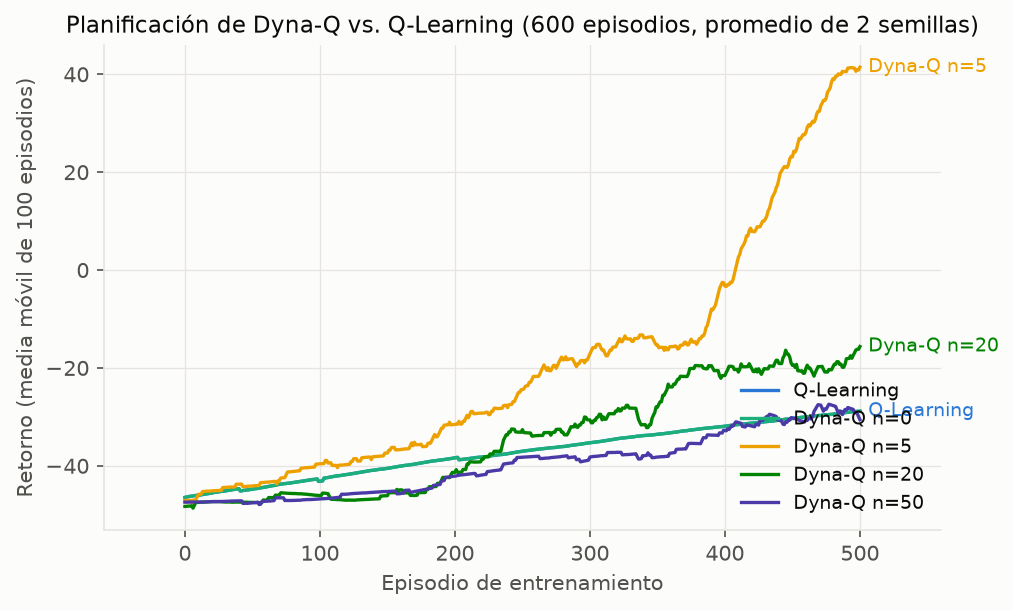

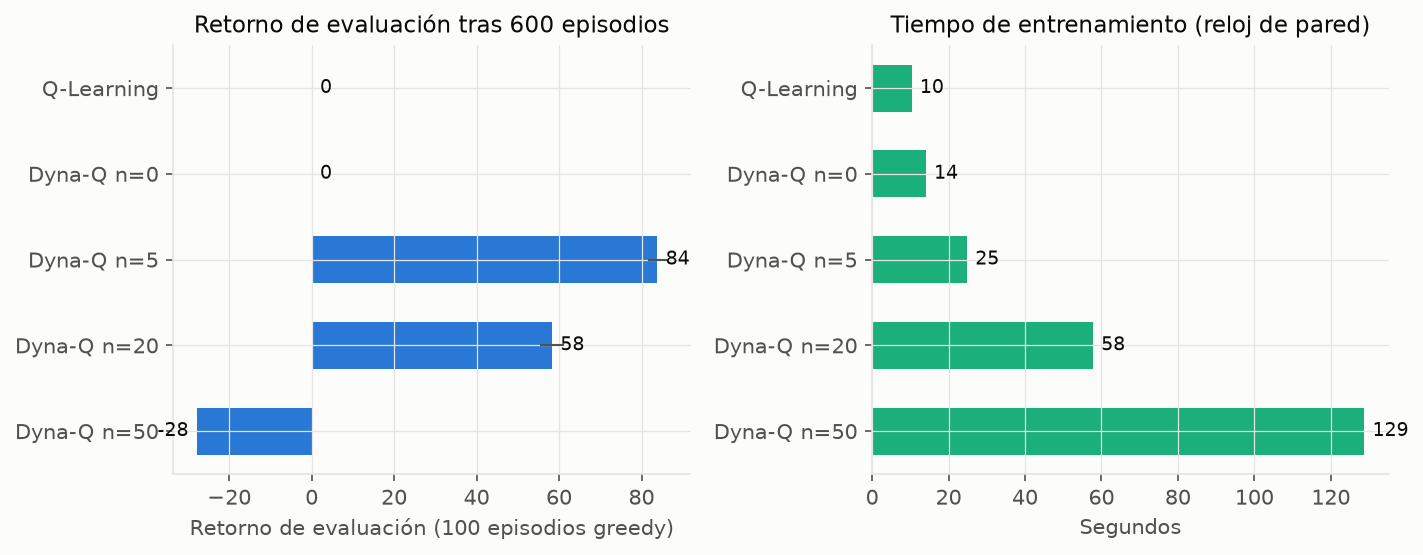

In [7]:
show_csv("results/dynaq_summary.csv",
         cols=["run_id", "planning_steps", "eval_mean_reward", "eval_success_rate",
               "train_seconds"])
display(Image("results/es/fig4_dynaq_curves.png"))
display(Image("results/es/fig5_dynaq_tradeoff.png"))

### Análisis

La suite corre deliberadamente sobre la discretización de **5 acciones** — la
que atrapa a Q-Learning puro — porque ahí es donde la planificación tiene algo
que demostrar. Resultados tras 600 episodios reales (2 semillas):

| Agente | Retorno eval. | Éxito | Tiempo |
|---|---|---|---|
| Q-Learning (y Dyna-Q n=0) | 0.0 | 0% | ~10–14 s |
| Dyna-Q **n=5** | **81.6 / 86.1** | **95–100%** | ~25 s |
| Dyna-Q n=20 | 55.5 / 61.1 | 72–86% | ~58 s |
| Dyna-Q n=50 | −27.9 / −27.9 | 0% | ~128 s |

Tres observaciones:

1. **n=0 reproduce exactamente a Q-Learning puro** — la maquinaria de Dyna no cambia nada por sí sola; verificación de sanidad superada.
2. **n=5 resuelve, en 600 episodios, la tarea que Q-Learning puro falló en 3 000** — con la acción "quieto" disponible y todo. Es la imagen de §8.2 del libro: cada éxito raro es repetido cientos de veces por la planificación, y el +100 barre la tabla en vez de arrastrarse una celda por éxito.
3. **Más planificación no es monótonamente mejor — n=50 es catastrófico.** Las repeticiones de planificación se muestrean uniformemente de *todas* las transiciones vistas, y antes del primer éxito esas transiciones solo contienen los costos de combustible −0.1a². Con n=50 esos costos se martillan en la tabla ~50 veces más rápido de lo que el comportamiento ε-greedy tarda en tropezar con la meta: toda acción de movimiento se vuelve profundamente negativa primero, el componente greedy deja de moverse, la meta nunca se encuentra — y la política final (−27.9 en ambas semillas) quema combustible en un vaivén inútil. n=20 queda a mitad de camino. Esta es precisamente la debilidad de la selección uniforme de muestras con la que Sutton & Barto motivan el **prioritized sweeping (§8.4)**: repetir las transiciones cuyos valores acaban de cambiar, no transiciones al azar.

El tiempo de pared crece ≈ linealmente con n, como se espera — la planificación
compra eficiencia de muestras con cómputo. Acá el tipo de cambio es excelente
en n=5 (2.5× el tiempo de Q-Learning puro, mejora infinita del resultado) y
ruinoso en n=50.

## Modelos finales (`experiments.py final`)

Se entregan tres modelos en `models/` (tablas Q serializadas con su
discretización):

- `final_qlearning.pkl` — Q-Learning puro con la configuración elegida (20×20 × 4 acciones, α=0.2, γ=0.99), 10 000 episodios. **Es el modelo computado principal de la entrega.**
- `final_dynaq_n5.pkl` — Dyna-Q con 5 pasos de planificación sobre la discretización de *5 acciones*: el escenario donde la planificación rescata de forma demostrable una tarea que Q-Learning puro falla, en 1 000 episodios reales.
- `final_qlearning_5actions.pkl` — la corrida de "escape": Q-Learning puro venciendo la trampa del "quieto" sin cambiar el conjunto de acciones, al precio de α=0.5, piso de ε 0.2 y 8 000 episodios.

run_id                    episodes  alpha  epsilon_min  planning_steps  eval_mean_reward   eval_std_reward     eval_success_rate  train_seconds     
final_qlearning           10000     0.2    0.05                         93.38199999105933  0.1644052491092492  1.0                38.68095874699998 
final_dynaq_n5            1000      0.1    0.05         5               77.559             15.828863872685245  0.99               34.817247829999815
final_qlearning_5actions  8000      0.5    0.2                          87.17125           26.751946044867267  0.98               55.62728521100007 


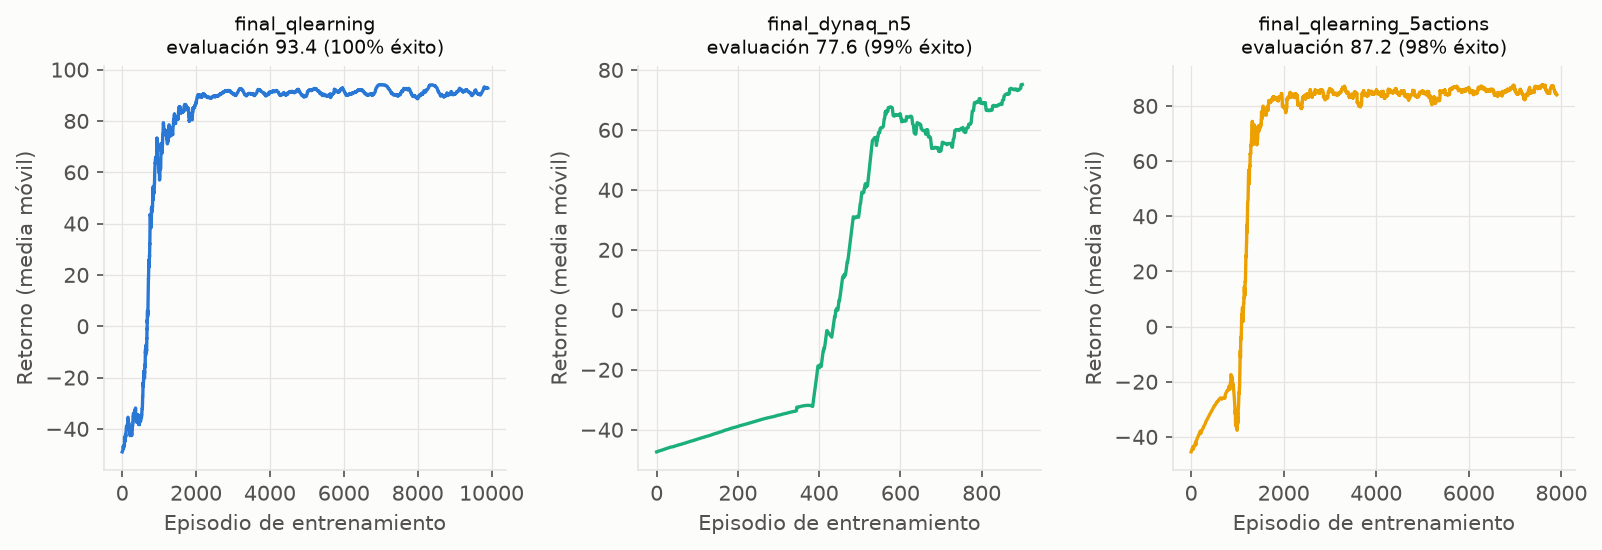

In [8]:
show_csv("results/final_summary.csv",
         cols=["run_id", "episodes", "alpha", "epsilon_min", "planning_steps",
               "eval_mean_reward", "eval_std_reward", "eval_success_rate", "train_seconds"])
display(Image("results/es/fig6_final_learning_curves.png"))

In [9]:
agent = QLearningAgent.load("models/final_qlearning.pkl")
test_env = gym.make("MountainCarContinuous-v0")
test_env.reset(seed=999)  # estados iniciales frescos, semilla nunca vista
results = agent.test_agent(test_env, episodes=20)
print(f"final_qlearning.pkl sobre 20 episodios frescos: "
      f"retorno medio {np.mean(results['reward']):.1f} +- {np.std(results['reward']):.1f}, "
      f"tasa de éxito {np.mean(results['success']):.2f}, "
      f"pasos promedio {np.mean(results['steps']):.0f}")

final_qlearning.pkl sobre 20 episodios frescos: retorno medio 93.3 +- 0.2, tasa de éxito 1.00, pasos promedio 78


### ¿Qué aprendió efectivamente el agente?

La función de valor y la política greedy aprendidas sobre la grilla de estados:

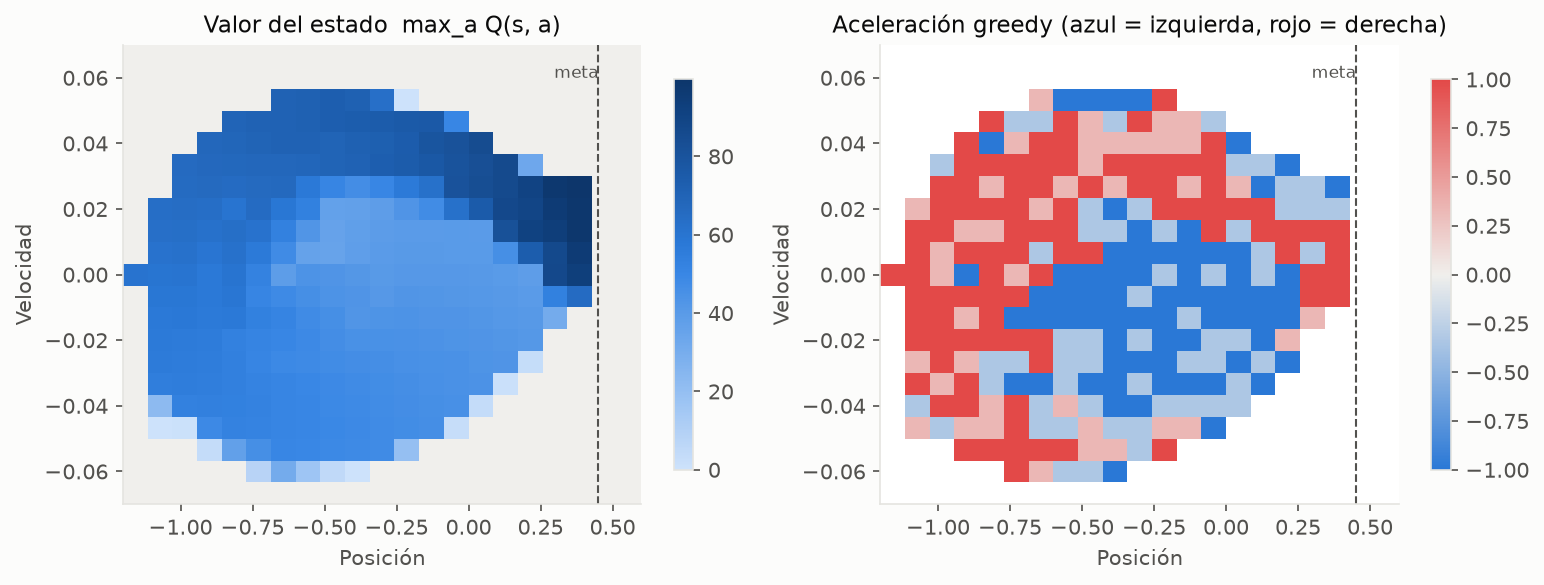

In [10]:
display(Image("results/es/fig7_policy_value.png"))

Los dos paneles muestran que el agente entendió la física:

- **Valor (izquierda):** máximo justo a la izquierda de la bandera con velocidad hacia la derecha, y a lo largo del "corredor de impulso" — el extremo izquierdo con velocidad también es valioso, porque una pasada por la pendiente izquierda catapulta al auto hacia la derecha. Las regiones cercanas a cero se visitaron poco o nunca (las celdas enmascaradas nunca se actualizaron).
- **Política (derecha):** un **controlador bang-bang aproximado organizado por la velocidad**: moviéndose a la derecha (mitad superior) → empujar a la derecha (rojo); moviéndose a la izquierda (mitad inferior) → empujar a la izquierda (azul). Es decir, empujar siempre *a favor* de la velocidad actual para bombear energía a la oscilación — exactamente la estrategia de resonancia que el problema exige. La frontera aproximadamente diagonal es donde el agente invierte el acelerador para convertir un vaivén hacia la izquierda en un lanzamiento hacia la derecha.

## Conclusiones

1. **La discretización fue la decisión de diseño decisiva, no la regla de aprendizaje.** Las grillas uniformes funcionan, pero la discretización de *acciones* carga una semántica escondida: todo conjunto de tamaño impar contiene una acción "quieto" gratuita que, combinada con el costo −0.1a², crea un óptimo local del que Q-Learning tabular no escapa de forma confiable en miles de episodios. Un conjunto par (sin "quieto") elimina la trampa estructuralmente. 20×20 × 4 acciones equilibra el aliasing contra los datos por celda.
2. **Q-Learning resuelve la tarea una vez que la representación es correcta:** ~93 de retorno medio, ~100% de éxito sobre 100 episodios greedy no vistos, soluciones de ~78 pasos — y la política greedy es un controlador bang-bang de impulso físicamente sensato.
3. **Los hiperparámetros importaron menos que la representación.** α = 0.2 y γ ≥ 0.99 son los únicos ajustes con efecto visible; el esquema de épsilon es casi irrelevante una vez que el movimiento es forzado. La dificultad de la tarea vive en la exploración y la asignación de crédito, no en el ajuste fino.
4. **Dyna-Q (§8.1–8.2) cumple su promesa de libro — con una salvedad que el propio libro predice.** n=5 pasos de planificación resolvieron, en 600 episodios, la configuración exacta que Q-Learning puro falló con 5 veces ese presupuesto; pero la planificación uniforme sobre experiencia que solo contiene costos es veneno en ambientes de recompensa engañosa (n=50 falla por completo), que es justamente la motivación del prioritized sweeping (§8.4).

**Notas de advertencia.** Los resultados provienen de 2 semillas por
configuración (presupuesto de cómputo); los números individuales cargan algunos
puntos de ruido de semilla, aunque toda conclusión cualitativa (acciones pares
vs. impares, la curva de n en Dyna-Q, γ = 0.9) es consistente entre semillas.
El truncamiento a 999 pasos se trata como no terminal en la actualización (se
mantiene el bootstrap), que es el manejo correcto de los límites de tiempo. No
se usó reward shaping en ningún experimento.